# Individual Energy-Profile Prediction — curve-approach evaluation

The per-activity **individual curve** prediction benchmark (Baseline, ML DTW,
ML + Ext. Factors, Seq2Seq, …) — the same evaluation as in `results_latex_table`,
extracted on its own.

- Source: `curve_eval_results.parquet` (per-curve records with an **Activity**
  dimension, unlike the `summary_train_test` file the old notebook used).
- Granularity: aggregated **process × activity × sensor**, then across those with
  the **median** (metrics: sMAE, sRMSE, WAPE).
- One table **per process** (all methods) + one **aggregated** table (all
  processes), both as styled tables and LaTeX.
- **Boxplots** of the aggregated per-(process, activity, sensor) values, in the
  same style as the sMAE boxplot in `results_latex_table`.

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

EXPERIMENT = 964
SPLIT      = 'TEST'                       # 'TEST' or 'TRAIN'
METRICS    = ['sMAE', 'sRMSE', 'WAPE']    # WAPE is a percentage
BOX_METRIC = 'sMAE'                       # metric for the boxplots
EXCLUDE_APPROACHES = []                   # e.g. ['ML only (no DTW)'] to drop variants
SAVE_LATEX = True

# Curve-length floor, applied to EVERY approach before any table or figure.
# The pipeline does not score the same curves for every approach: the
# *_external ones are evaluated through split_curves_with_prev_activity, which
# keeps curves with >= 5 samples, while every other approach goes through
# split_curves, which keeps >= 2. Curves 2-4 samples long therefore exist for
# six approaches and not for the two prev-activity ones (experiment_964:
# 30,080 vs 26,000 TEST curves), so the raw columns are medians over different
# populations. Filtering here levels them; set to 0 to see the raw behaviour.
MIN_CURVE_POINTS = 5

# ── Method names as they should read everywhere (tables, LaTeX, boxplots) ────
# Keys are the raw `Approach` values in curve_eval_results.parquet; anything not
# listed keeps its raw name. Applied right after loading, so every downstream
# table and figure uses these names. NOTE: the raw 'Median per Activity & Sensor'
# must not survive into LaTeX — a bare '&' would be read as a column separator.
METHOD_RENAME = {
    'ML + Ext. Factors':                       'DTW + ML + Ext. Factors',
    'ML DTW':                                  'DTW + ML',
    'Median per Activity & Sensor':            'Median per activity and sensor',
    'DTW + Seq2Seq + Ext. Factors':            'DTW + Seq2Seq + Ext. Factors',
}

results_root = Path('..') / 'results'
runs = sorted([d for d in results_root.iterdir()
               if d.is_dir() and d.name.startswith(f'experiment_{EXPERIMENT}_')])
assert runs, f'No runs for experiment {EXPERIMENT}'
run_dir = runs[-1]
print('Using run:', run_dir.name)

In [ ]:
# ── Load + aggregate to (process, activity, sensor, approach) ────────────────
raw = pd.read_parquet(run_dir / 'curve_eval_results.parquet')
raw = raw[raw['Split'] == SPLIT]
if EXCLUDE_APPROACHES:                       # exclusion uses the RAW names
    raw = raw[~raw['Approach'].isin(EXCLUDE_APPROACHES)]

# Level the population across approaches (see MIN_CURVE_POINTS).
if MIN_CURVE_POINTS:
    _before = raw.groupby('Approach').size()
    raw = raw[raw['N'] >= MIN_CURVE_POINTS]
    _after = raw.groupby('Approach').size()
    _levelling = pd.DataFrame({'curves_raw': _before, 'curves_used': _after}).fillna(0).astype(int)
    _levelling['dropped'] = _levelling['curves_raw'] - _levelling['curves_used']
    display(Markdown(f'**Population levelled to curves with $\\geq$ {MIN_CURVE_POINTS} samples**'))
    display(_levelling)
    if _levelling['curves_used'].nunique() > 1:
        print('⚠️ curve counts still differ across approaches after levelling — '
              'the comparison is not like-for-like.')

raw['Approach'] = raw['Approach'].replace(METHOD_RENAME)   # display names from here on
print(f'{len(raw):,} per-curve rows | approaches: {raw["Approach"].nunique()} | '
      f'processes: {sorted(raw["Process"].unique())}')
print('methods:', sorted(raw['Approach'].unique()))

# Stage 1: one value per (process, activity, sensor, approach) = median over its curves
combo = (raw.groupby(['Process', 'Activity', 'Sensor', 'Approach'])[METRICS]
            .median().reset_index())
print('per (process, activity, sensor, approach) rows:', len(combo))

In [3]:
# ── Table helpers (bold best per column; lower = better) ─────────────────────
# Row labels come from METHOD_RENAME, which is already applied to the data in the
# load cell; it is reapplied here so the tables stay correct even if that cell is
# re-run out of order.
# Column headers in the paper table.
PAPER_HDR = {'sMAE': 'sMAE', 'sRMSE': 'sRMSE', 'WAPE': r'WAPE (\%)'}
# Widths of the paper float — tweak if the table doesn't fit the column.
PAPER_MINIPAGE = '8.5cm'    # minipage holding caption + tabular
PAPER_FIRSTCOL = '6cm'      # p{} width of the method column
PAPER_NOTEBOX  = '12cm'     # parbox width of the note under the table
PAPER_DECIMALS = 3

def _tex(s):
    # Escape the LaTeX specials that can appear in method / process names.
    return (str(s).replace('\\', r'\textbackslash ').replace('&', r'\&')
                  .replace('_', r'\_').replace('%', r'\%').replace('#', r'\#'))

def _row_label(idx):
    return _tex(METHOD_RENAME.get(idx, idx))

def approach_table(df_combo):
    # median across (activity, sensor[, process]) per approach
    t = df_combo.groupby('Approach')[METRICS].median()
    return t.sort_values(BOX_METRIC)          # best (lowest) first

def style_table(t):
    return (t.style.format({m: '{:.3f}' for m in t.columns}, na_rep='—')
             .highlight_min(axis=0, props='font-weight:700;background-color:#d6ecff;')
             .set_caption(f'{SPLIT} — median over process×activity×sensor; lower = better'))

def _cells(t, dp=3):
    # Formatted strings with the per-column minimum bolded.
    s = pd.DataFrame(index=t.index, columns=t.columns, dtype=object)
    for col in t.columns:
        vals = t[col].dropna(); best = vals.min() if not vals.empty else None
        for idx in t.index:
            v = t.loc[idx, col]
            s.loc[idx, col] = ('' if pd.isna(v) else
                               (r'\textbf{' + f'{v:.{dp}f}' + '}')
                               if (best is not None and abs(v - best) < 1e-6)
                               else f'{v:.{dp}f}')
    return s

def to_latex(t, caption, label):
    s = _cells(t)
    s.index = [_row_label(i) for i in t.index]
    latex = s.to_latex(escape=False, column_format='l|' + '|'.join(['c']*len(t.columns)),
                       caption=caption, label=label, position='H')
    return latex

def to_latex_paper(t, caption, label, note):
    # Paper float: table* + minipage, caption on top, booktabs rules, bold header
    # row, and a \parbox note underneath. Needs booktabs + caption in the preamble.
    s = _cells(t, PAPER_DECIMALS)
    body = '\n'.join(' & '.join([_row_label(idx)] + [s.loc[idx, c] for c in t.columns]) + r' \\'
                     for idx in t.index)
    hdr = ' & '.join([r'\textbf{Method}']
                     + [r'\textbf{' + PAPER_HDR.get(c, _tex(c)) + '}' for c in t.columns])
    return '\n'.join([
        r'\begin{table*}[H]',
        r'\centering',
        '',
        rf'\begin{{minipage}}{{{PAPER_MINIPAGE}}}',
        r'\centering',
        '',
        r'\captionsetup{',
        r'    justification=centering,',
        r'    singlelinecheck=false,',
        r'    format=plain',
        r'}',
        '',
        rf'\caption{{{caption}}}',
        rf'\label{{{label}}}',
        '',
        r'\vspace{-0.5em}',
        '',
        rf'\begin{{tabular}}{{p{{{PAPER_FIRSTCOL}}}|' + '|'.join(['c'] * len(t.columns)) + '}',
        r'\toprule',
        hdr + r' \\',
        r'\midrule',
        body,
        r'\bottomrule',
        r'\end{tabular}',
        '',
        r'\vspace{0.5em}',
        '',
        rf'\parbox{{{PAPER_NOTEBOX}}}{{%',
        r'\footnotesize',
        note,
        r'}',
        '',
        r'\end{minipage}',
        '',
        r'\end{table*}',
    ])

## 1 · Aggregated — all processes

In [4]:
agg = approach_table(combo)
display(style_table(agg))

,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML + Ext. Factors,1.134,1.368,6.674
DTW + ML,1.354,1.666,7.548
Median per activity and sensor,1.477,1.755,7.700
DTW + Seq2Seq + Ext. Factors,1.502,1.743,7.836
DTW + Seq2Seq,1.539,1.796,8.206
ML only (no DTW),1.619,1.857,8.403
Baseline,1.630,1.879,8.457
Seq2Seq only (no DTW),1.744,1.986,8.960


## 2 · Per process (all methods)

In [5]:
per_process = {}
for proc in sorted(combo['Process'].unique()):
    t = approach_table(combo[combo['Process'] == proc])
    per_process[proc] = t
    display(Markdown(f'### {proc}'))
    display(style_table(t))

### process_1

,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML,0.797,1.003,7.103
DTW + ML + Ext. Factors,0.820,1.021,7.160
DTW + Seq2Seq + Ext. Factors,0.828,1.019,7.313
DTW + Seq2Seq,0.844,1.021,7.287
Median per activity and sensor,0.853,1.037,7.603
ML only (no DTW),0.853,1.034,7.842
Seq2Seq only (no DTW),0.856,1.029,7.666
Baseline,0.916,1.083,7.834


### process_2

,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML,0.428,0.794,32.848
DTW + ML + Ext. Factors,0.452,0.824,27.873
DTW + Seq2Seq,0.577,1.008,50.164
Median per activity and sensor,0.585,1.009,36.027
DTW + Seq2Seq + Ext. Factors,0.683,0.975,50.315
ML only (no DTW),0.773,1.040,42.304
Seq2Seq only (no DTW),0.905,1.025,52.178
Baseline,1.565,1.682,84.372


### process_3

...

,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML + Ext. Factors,1.981,2.189,5.782
Median per activity and sensor,2.390,2.599,6.516
DTW + Seq2Seq,2.531,2.720,9.133
DTW + Seq2Seq + Ext. Factors,2.539,2.729,8.281
Baseline,2.543,2.715,6.502
DTW + ML,2.557,2.723,8.773
Seq2Seq only (no DTW),2.606,2.804,8.626
ML only (no DTW),2.798,2.975,8.981


### process_4_2

,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML + Ext. Factors,3.761,3.864,7.975
Median per activity and sensor,3.814,3.950,14.072
DTW + Seq2Seq + Ext. Factors,3.926,4.077,9.509
Seq2Seq only (no DTW),4.465,4.481,14.871
DTW + Seq2Seq,4.636,4.767,14.843
DTW + ML,4.669,4.734,14.253
Baseline,4.918,5.031,16.303
ML only (no DTW),5.204,5.306,15.463


### process_5

,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML + Ext. Factors,1.162,1.401,3.482
DTW + ML,1.819,2.044,6.087
DTW + Seq2Seq,1.953,2.207,6.649
DTW + Seq2Seq + Ext. Factors,1.956,2.185,6.019
Baseline,2.035,2.242,6.328
Median per activity and sensor,2.118,2.299,5.784
ML only (no DTW),2.342,2.552,7.096
Seq2Seq only (no DTW),2.450,2.692,9.168


## 3 · LaTeX

In [6]:
# LaTeX is printed only — no process_metrics_tables/ folder is written.
# The aggregated table is emitted in the paper layout (table* + minipage + note);
# the per-process ones stay in the plain compact layout.

AGG_LABEL = 'tab:energy_results_median_overall'   # label the paper \ref's

tex_agg = to_latex_paper(agg,
    caption='Results for individual profile prediction. ',
    label=AGG_LABEL,
    note=('Standardized median test results per method, across sensors and activities.\n'
          'Lower values are better. Rows are sorted best-to-worst by sMAE.\n'
          r'\textbf{Bold} indicates the best value per metric. The baseline is the '
          'median value of the sensor.'))
print('% ===== ALL PROCESSES ====='); print(tex_agg)

for proc, t in per_process.items():
    tex = to_latex(t,
        caption=(f'Individual energy-profile prediction for {_tex(proc)} ({SPLIT} set). Median over '
                 r'(activity, sensor) of each curve metric; lower is better. '
                 r'\textbf{Bold} = best approach per metric.'),
        label=f'tab:individual_profile_{proc}_{EXPERIMENT}')
    print(f'\n% ===== {proc} ====='); print(tex)


% ===== ALL PROCESSES =====
\begin{table*}[H]
\centering

\begin{minipage}{8.5cm}
\centering

\captionsetup{
    justification=centering,
    singlelinecheck=false,
    format=plain
}

\caption{Results for individual profile prediction. }
\label{tab:energy_results_median_overall}

\vspace{-0.5em}

\begin{tabular}{p{6cm}|c|c|c}
\toprule
\textbf{Method} & \textbf{sMAE} & \textbf{sRMSE} & \textbf{WAPE (\%)} \\
\midrule
DTW + ML + Ext. Factors & \textbf{1.134} & \textbf{1.368} & \textbf{6.674} \\
DTW + ML & 1.354 & 1.666 & 7.548 \\
Median per activity and sensor & 1.477 & 1.755 & 7.700 \\
DTW + Seq2Seq + Ext. Factors & 1.502 & 1.743 & 7.836 \\
DTW + Seq2Seq & 1.539 & 1.796 & 8.206 \\
ML only (no DTW) & 1.619 & 1.857 & 8.403 \\
Baseline & 1.630 & 1.879 & 8.457 \\
Seq2Seq only (no DTW) & 1.744 & 1.986 & 8.960 \\
\bottomrule
\end{tabular}

\vspace{0.5em}

\parbox{12cm}{%
\footnotesize
Standardized median test results per method, across sensors and activities.
Lower values are better. Rows are

## 4 · Boxplot — aggregated per (process, activity, sensor)

Same style as the sMAE boxplot in `results_latex_table`: one box per approach over
all (process, activity, sensor) values, sorted best-at-top, x-axis capped near the
95th percentile.

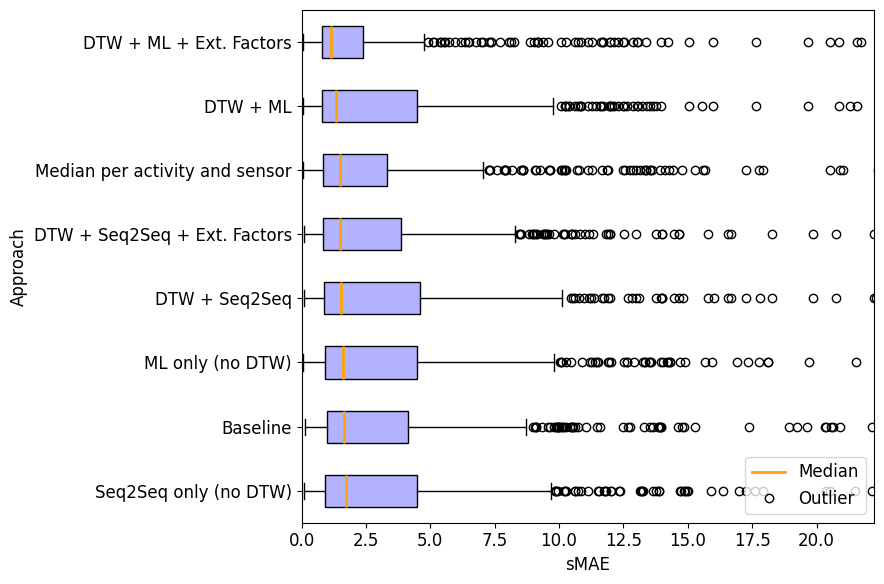

Saved: visuals/individual_profile_sMAE_boxplot.pdf


In [7]:
plt.rcParams.update({'font.size': 12})
df_box = combo[~combo['Approach'].isin(EXCLUDE_APPROACHES)]
box_order = df_box.groupby('Approach')[BOX_METRIC].median().sort_values(ascending=False).index.tolist()
data = [df_box.loc[df_box['Approach'] == a, BOX_METRIC].dropna().values for a in box_order]

fig, ax = plt.subplots(figsize=(9, 6))
bplot = ax.boxplot(data, tick_labels=box_order, showfliers=True, vert=False,
                   patch_artist=True, medianprops=dict(color='orange', linewidth=2))
blue_rgba = mcolors.to_rgba('blue', alpha=0.3)
for patch in bplot['boxes']:
    patch.set_facecolor(blue_rgba); patch.set_edgecolor('black')
all_vals = np.concatenate([d for d in data if len(d)])
ax.set_xlim(0, np.percentile(all_vals, 95) * 1.3)
ax.set_xlabel(BOX_METRIC); ax.set_ylabel('Approach')
ax.legend(handles=[Line2D([0],[0],color='orange',lw=2,label='Median'),
                   Line2D([0],[0],marker='o',color='w',markeredgecolor='black',
                          markerfacecolor='none',markersize=6,label='Outlier')], loc='lower right')
fig.tight_layout()
Path('visuals').mkdir(exist_ok=True)
fig.savefig(f'visuals/individual_profile_{BOX_METRIC}_boxplot.pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: visuals/individual_profile_{BOX_METRIC}_boxplot.pdf')

### Boxplots for every metric

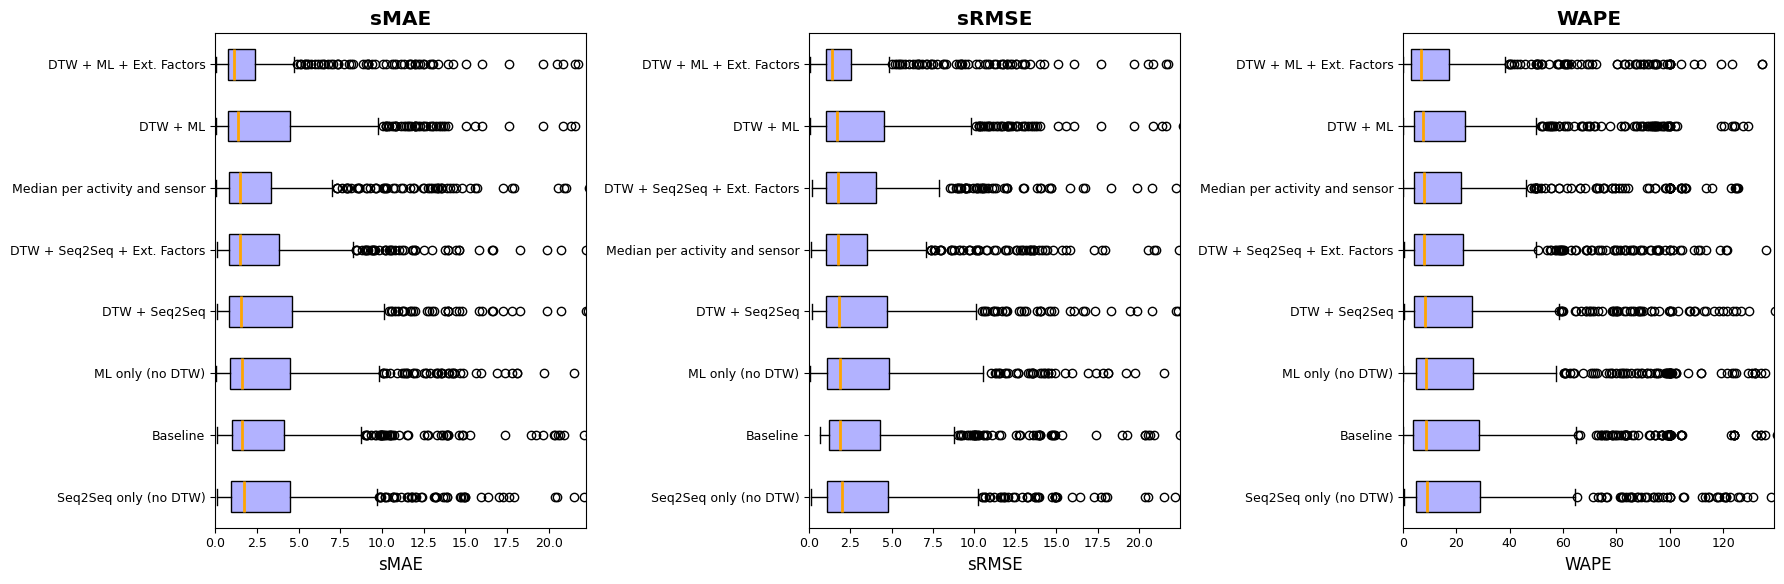

In [8]:
metrics = METRICS
fig, axes = plt.subplots(1, len(metrics), figsize=(6*len(metrics), 6))
axes = np.atleast_1d(axes)
for ax, metric in zip(axes, metrics):
    order = df_box.groupby('Approach')[metric].median().sort_values(ascending=False).index.tolist()
    data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in order]
    bp = ax.boxplot(data, tick_labels=order, showfliers=True, vert=False,
                    patch_artist=True, medianprops=dict(color='orange', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(blue_rgba); patch.set_edgecolor('black')
    av = np.concatenate([d for d in data if len(d)])
    if len(av): ax.set_xlim(0, np.percentile(av, 95) * 1.3)
    ax.set_xlabel(metric); ax.set_title(metric, fontweight='bold')
    ax.tick_params(labelsize=9)
fig.tight_layout()
plt.show()